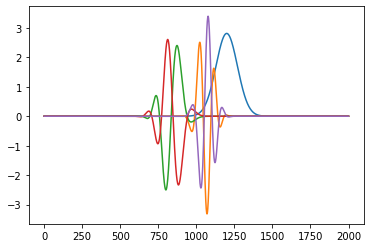

In [35]:
import wave_packet_dynamics as wpd
from matplotlib import pyplot as plt

bounds = (-1, 1)
points = 2001
grid = wpd.Grid(bounds, points)

from wave_packet_dynamics import wave_function as wave
from wave_packet_dynamics import potential as pot
from functools import partial

gaussian_function = partial(wave.gaussian, sigma=0.05, x0=0.2, k0=0)
wave_function = wpd.WaveFunction(grid, gaussian_function)

harmonic_function = partial(pot.harmonic, k=1 * 10 ** 5, x0=0)
potential = wpd.Potential(grid, harmonic_function)

time_increment = 5 * 10 ** -5
time_evo_op = wpd.TimeEvolutionOperator(grid, wave_function.mass, potential, time_increment, accuracy=6)
for t in range(400):
    wave_function = time_evo_op.map(wave_function)
    if t % 80 == 0:
        plt.plot(wave_function.values.real)
plt.show()